In [ ]:
!apt-get install -y poppler-utils tesseract-ocr

In [ ]:
!pip install pdf2image opencv-python pillow matplotlib
!pip install pix2tex[api]

## Step 1 — Upload PDF

In [ ]:
from google.colab import files

uploaded = files.upload()
PDF_PATH = list(uploaded.keys())[0]

## Step 2 — Convert PDF to Images

In [ ]:
from pdf2image import convert_from_path
import os

OUTPUT_DIR = "pages"
os.makedirs(OUTPUT_DIR, exist_ok=True)

pages = convert_from_path(PDF_PATH, dpi=400)

for i, page in enumerate(pages):
    path = f"{OUTPUT_DIR}/page_{i+1}.png"
    page.save(path, "PNG")
    print("Saved:", path)

print("PDF to images done.")

## Step 3 — Extract Red Rectangular Boxes (Crops)


In [37]:
import cv2
import numpy as np
import os

CROP_DIR = "equation_crops"
os.makedirs(CROP_DIR, exist_ok=True)

def extract_red_boxes(image_path, page_idx):
    img = cv2.imread(image_path)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # RED RANGE  (red wraps around 0/180 in HSV, two ranges needed)
    lower_red1 = np.array([0,   70, 50])
    upper_red1 = np.array([10, 255, 255])
    lower_red2 = np.array([160, 70, 50])
    upper_red2 = np.array([180, 255, 255])

    mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
    mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
    mask  = cv2.bitwise_or(mask1, mask2)

    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    crops = []

    for i, cnt in enumerate(contours):
        area = cv2.contourArea(cnt)
        peri = cv2.arcLength(cnt, True)

        if area < 1000:
            continue

        # rectangle check
        approx = cv2.approxPolyDP(cnt, 0.02 * peri, True)
        if len(approx) != 4:
            continue

        x, y, w, h = cv2.boundingRect(cnt)

        crop = img[y:y+h, x:x+w]
        crop_path = f"{CROP_DIR}/page{page_idx}_box{i}.png"
        cv2.imwrite(crop_path, crop)
        crops.append(crop_path)

    return crops

Total cropped regions: 33
Saved in folder: equation_crops

Displaying cropped images:



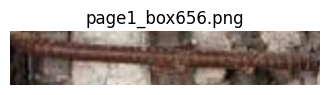

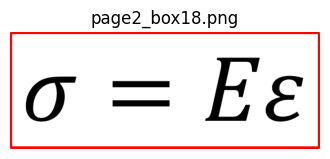

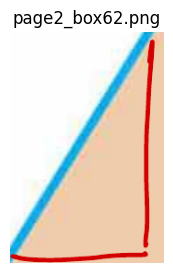

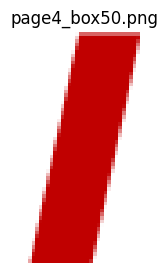

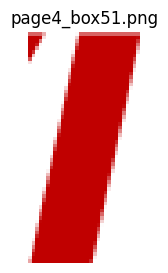

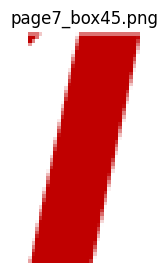

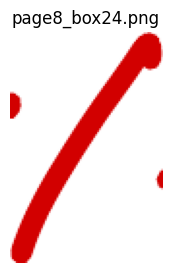

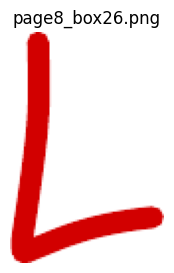

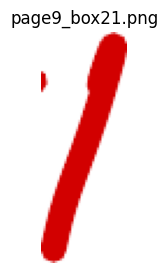

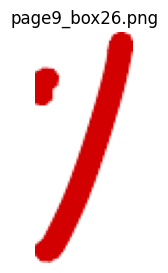

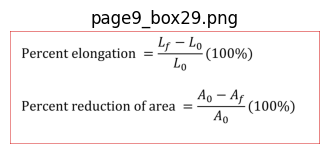

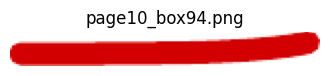

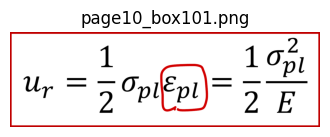

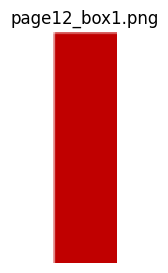

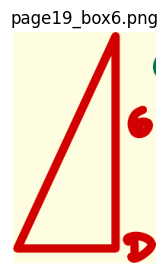

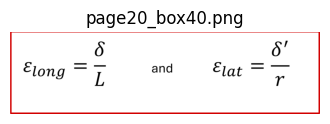

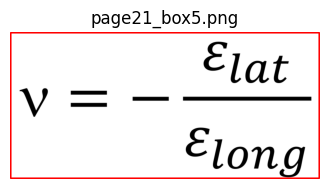

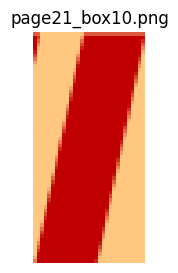

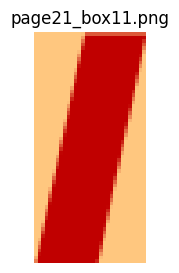

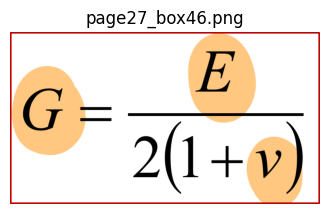

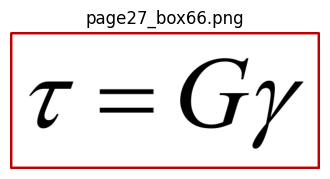

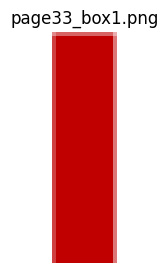

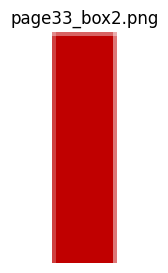

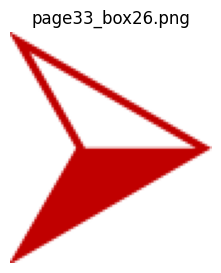

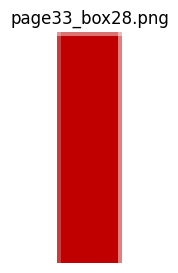

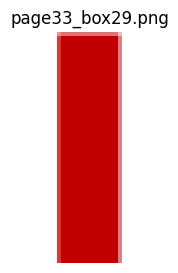

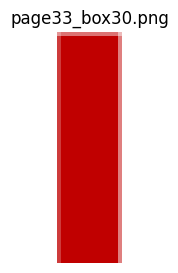

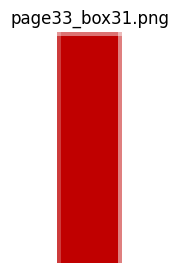

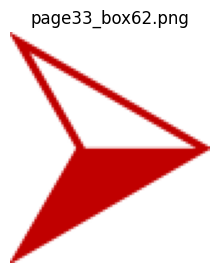

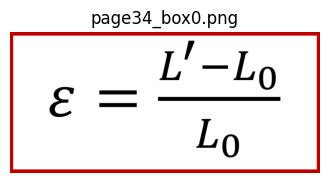

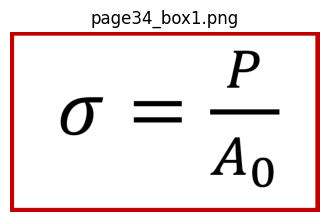

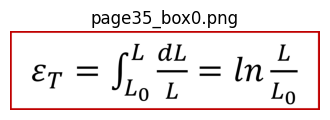

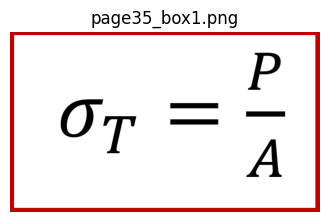

In [38]:
import os
import matplotlib.pyplot as plt
from PIL import Image

all_crops = []

for idx, img_name in enumerate(sorted(os.listdir("pages"))):
    img_path = os.path.join("pages", img_name)
    all_crops.extend(extract_red_boxes(img_path, idx + 1))

print("Total cropped regions:", len(all_crops))
print("Saved in folder:", CROP_DIR)

# --- Display ONLY filtered images ---
print(f"\nDisplaying cropped images:\n")

from IPython.display import display as ipy_display

for img_path in all_crops:
    img = Image.open(img_path)

    fig, ax = plt.subplots(figsize=(4, 3))
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(os.path.basename(img_path))

    ipy_display(fig)
    plt.close(fig)

## Step 4 — Hough Rectangle Filter


In [39]:
import cv2
import numpy as np

def has_red_rectangle_hough(image_path,
                            min_line_length=60,
                            max_line_gap=10,
                            angle_tol=10):
    img = cv2.imread(image_path)
    if img is None:
        return False

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # --- RED mask ---
    lower_red1 = np.array([0,   70, 50])
    upper_red1 = np.array([10, 255, 255])
    lower_red2 = np.array([160, 70, 50])
    upper_red2 = np.array([180, 255, 255])

    mask = cv2.bitwise_or(
        cv2.inRange(hsv, lower_red1, upper_red1),
        cv2.inRange(hsv, lower_red2, upper_red2)
    )

    # Clean noise
    kernel = np.ones((3, 3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # Edge detection
    edges = cv2.Canny(mask, 50, 150, apertureSize=3)

    # Hough Line Transform
    lines = cv2.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi / 180,
        threshold=80,
        minLineLength=min_line_length,
        maxLineGap=max_line_gap
    )

    if lines is None:
        return False

    horizontal = 0
    vertical   = 0

    for line in lines:
        x1, y1, x2, y2 = line[0]
        angle = abs(np.degrees(np.arctan2(y2 - y1, x2 - x1)))

        # Horizontal line
        if angle < angle_tol or angle > (180 - angle_tol):
            horizontal += 1

        # Vertical line
        elif abs(angle - 90) < angle_tol:
            vertical += 1

    # Rectangle condition
    return horizontal >= 2 and vertical >= 2

=== Hough Rectangle Detection ===
Total images     : 33
Filtered (kept)  : 12
Removed          : 21

Displaying filtered images:



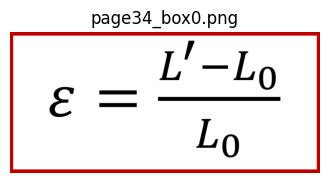

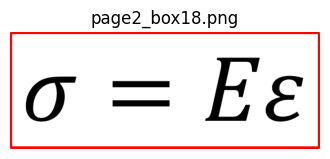

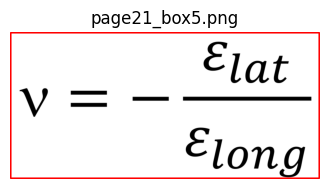

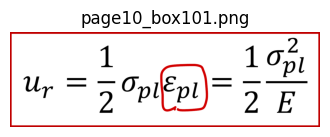

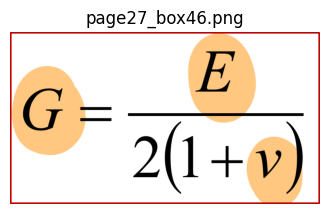

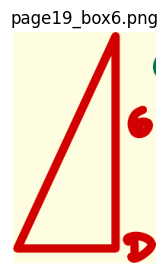

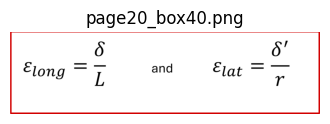

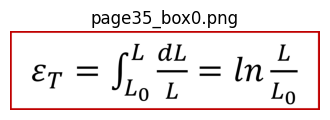

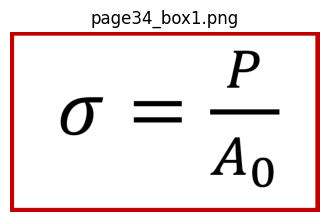

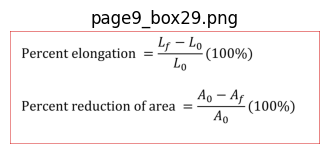

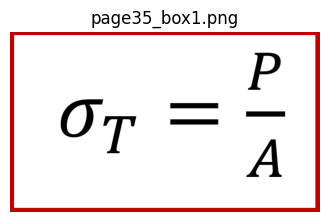

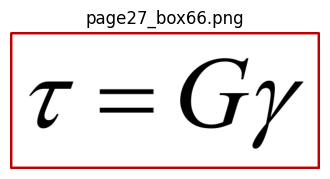

In [40]:
import os
import matplotlib.pyplot as plt
from PIL import Image

image_dir = "/content/equation_crops"

filtered_images = []
removed_images  = []

# --- Filtering ---
for img_name in os.listdir(image_dir):
    if not img_name.lower().endswith((".png", ".jpg", ".jpeg")):
        continue

    img_path = os.path.join(image_dir, img_name)

    if has_red_rectangle_hough(img_path):
        filtered_images.append(img_path)
    else:
        removed_images.append(img_path)

# --- Summary ---
print("=== Hough Rectangle Detection ===")
print(f"Total images     : {len(filtered_images) + len(removed_images)}")
print(f"Filtered (kept)  : {len(filtered_images)}")
print(f"Removed          : {len(removed_images)}")

# --- Display ONLY filtered images ---
print("\nDisplaying filtered images:\n")

from IPython.display import display as ipy_display

for img_path in filtered_images:
    img = Image.open(img_path)

    fig, ax = plt.subplots(figsize=(4, 3))
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(os.path.basename(img_path))

    ipy_display(fig)
    plt.close(fig)

## Step 5 — Preprocess & LaTeX OCR with pix2tex

## ------------- 5(a) Preprocessing

In [41]:
import cv2
import numpy as np

def remove_red_border(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # RED RANGE
    lower_red1 = np.array([0,   70, 50])
    upper_red1 = np.array([10, 255, 255])
    lower_red2 = np.array([160, 70, 50])
    upper_red2 = np.array([180, 255, 255])

    mask = cv2.bitwise_or(
        cv2.inRange(hsv, lower_red1, upper_red1),
        cv2.inRange(hsv, lower_red2, upper_red2)
    )

    img[mask > 0] = [255, 255, 255]  # paint red as white
    return img


def binarize(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, bw = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return bw


def tight_crop(img):
    coords = cv2.findNonZero(255 - img)
    x, y, w, h = cv2.boundingRect(coords)
    return img[y:y+h, x:x+w]


def deskew(img):
    gray   = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    coords = cv2.findNonZero(255 - gray)
    angle  = cv2.minAreaRect(coords)[-1]

    if angle < -45:
        angle = -(90 + angle)
    else:
        angle = -angle

    (h, w) = img.shape[:2]
    M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
    return cv2.warpAffine(img, M, (w, h),
                          flags=cv2.INTER_CUBIC,
                          borderMode=cv2.BORDER_REPLICATE)


def enhance_spacing(img):
    gray   = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    return cv2.morphologyEx(gray, cv2.MORPH_OPEN, kernel)


def add_padding(img, pad=20):
    return cv2.copyMakeBorder(
        img, pad, pad, pad, pad,
        cv2.BORDER_CONSTANT, value=255
    )

## ------------- 5(b) LaTeX OCR

In [42]:
from pix2tex.cli import LatexOCR
from PIL import Image
import os
import cv2

model = LatexOCR()

all_equations = []

for img_path in filtered_images:
    img = cv2.imread(img_path)

    img = remove_red_border(img)
    img = deskew(img)
    img = enhance_spacing(img)
    img = tight_crop(img)
    img = add_padding(img, 30)

    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

    pil_img = Image.fromarray(img)

    pil_img = pil_img.resize((pil_img.width * 2, pil_img.height * 2), Image.LANCZOS)

    latex = model(pil_img)
    print(img_path, "→", latex)

    all_equations.append(latex)

/content/equation_crops/page34_box0.png → {\mathcal{E}}\simeq{\frac{2^{\prime}\!-\!\!2_{o}}{2_{o}}}
/content/equation_crops/page2_box18.png → \sigma=E\varepsilon
/content/equation_crops/page21_box5.png → \displaystyle\mathbf{v}=-{\frac{\varepsilon_{l a t}}{\varepsilon_{l o n g}}}
/content/equation_crops/page10_box101.png → u_{r}=\frac{1}{2}O_{p l}\varepsilon_{p l}=\frac{1}{2}\frac{G_{p l}^{2}}{E}
/content/equation_crops/page27_box46.png → \begin{array}{c}{{G_{\it1}}}\\ {{\longrightarrow}}\\ {{\sim}}\end{array}\frac{\overline{{{E}}}}{\sim}\overline{{{\langle1+\frac{\nu}{2}\rangle}}}\end{array}
/content/equation_crops/page19_box6.png → \left\langle\begin{array}{l l}\ \\ {
/content/equation_crops/page20_box40.png → \varepsilon_{l o n g}=\frac{\delta}{L}~~~~~~~\mathrm{and}~~~~~~\varepsilon_{l a t}=\frac{\delta^{\prime}}{r}
/content/equation_crops/page35_box0.png → \varepsilon_{T}\,\underline{{{=}}}\,\int_{L_{0}}^{L}\frac{d L}{L}\underline{{{\theta}}}\underline{{{\theta}}}\,\underline{{{L}}

## ------------- 5(c) Eq. Validation

In [43]:
from IPython.display import display, Math
import re

def clean_latex(eq):
    eq = eq.replace(r'\displaystyle', '').strip()
    eq = re.sub(r'\\begin\{array\}.*?\\end\{array\}', r'\\text{(unreadable)}', eq, flags=re.DOTALL)
    return eq.strip()

def is_valid_equation(eq):
    if not eq or not eq.strip():
        return False
    if '(unreadable)' in eq:
        return False
    if not re.search(r'[a-zA-Z0-9=]', eq):
        return False

    # Reject incomplete array environments (begin without end)
    if r'\begin{array}' in eq and r'\end{array}' not in eq:
        return False

    # Reject equations with unmatched \left without \right
    if eq.count(r'\left') != eq.count(r'\right'):
        return False

    readable = re.sub(r'\\[a-zA-Z]+', '', eq)
    readable = re.sub(r'[{}_^\\]', '', readable).strip()
    if len(readable) < 2:
        return False
    return True

all_equations_cleaned = []
for i, eq in enumerate(all_equations, 1):
    cleaned = clean_latex(eq)
    if not is_valid_equation(cleaned):
        print(f"REJECTED Equation {i}: '{cleaned[:60]}'")
        continue
    all_equations_cleaned.append(cleaned)
    print(f'\nEquation {len(all_equations_cleaned)}:\n')
    display(Math(cleaned))

print(f'\n{len(all_equations_cleaned)} valid equation(s) found')


Equation 1:



<IPython.core.display.Math object>


Equation 2:



<IPython.core.display.Math object>


Equation 3:



...


Equation 9:



<IPython.core.display.Math object>


Equation 10:



<IPython.core.display.Math object>


10 valid equation(s) found


In [46]:
latex_file = "equations.tex"

with open(latex_file, "w") as f:

    f.write("\\documentclass{article}\n")
    f.write("\\usepackage{amsmath}\n")
    f.write("\\usepackage{amssymb}\n")
    f.write("\\begin{document}\n\n")

    f.write("\\section*{Extracted Equations}\n\n")

    for i, eq in enumerate(all_equations_cleaned, 1):

        f.write(f"\\textbf{{Equation {i}:}}\n")
        f.write("\\[\n")
        f.write(eq + "\n")
        f.write("\\]\n\n")

    f.write("\\end{document}")

print(f"{len(all_equations_cleaned)} equations saved to {latex_file}")

10 equations saved to equations.tex


In [47]:
from google.colab import files
files.download("equations.tex")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>